✅ Data loaded: (150000, 21)
✅ Dashboard saved at /mnt/user-data/outputs/ncr_dashboard.png

✨ KEY INSIGHTS
--------------------------------------------------
Total Revenue: ₹51,846,183
Total Profit : ₹18,146,164
Cancellation Rate: 34.04%
💡 Potential Revenue Gain: ₹12,196,277

✅ Analysis Complete


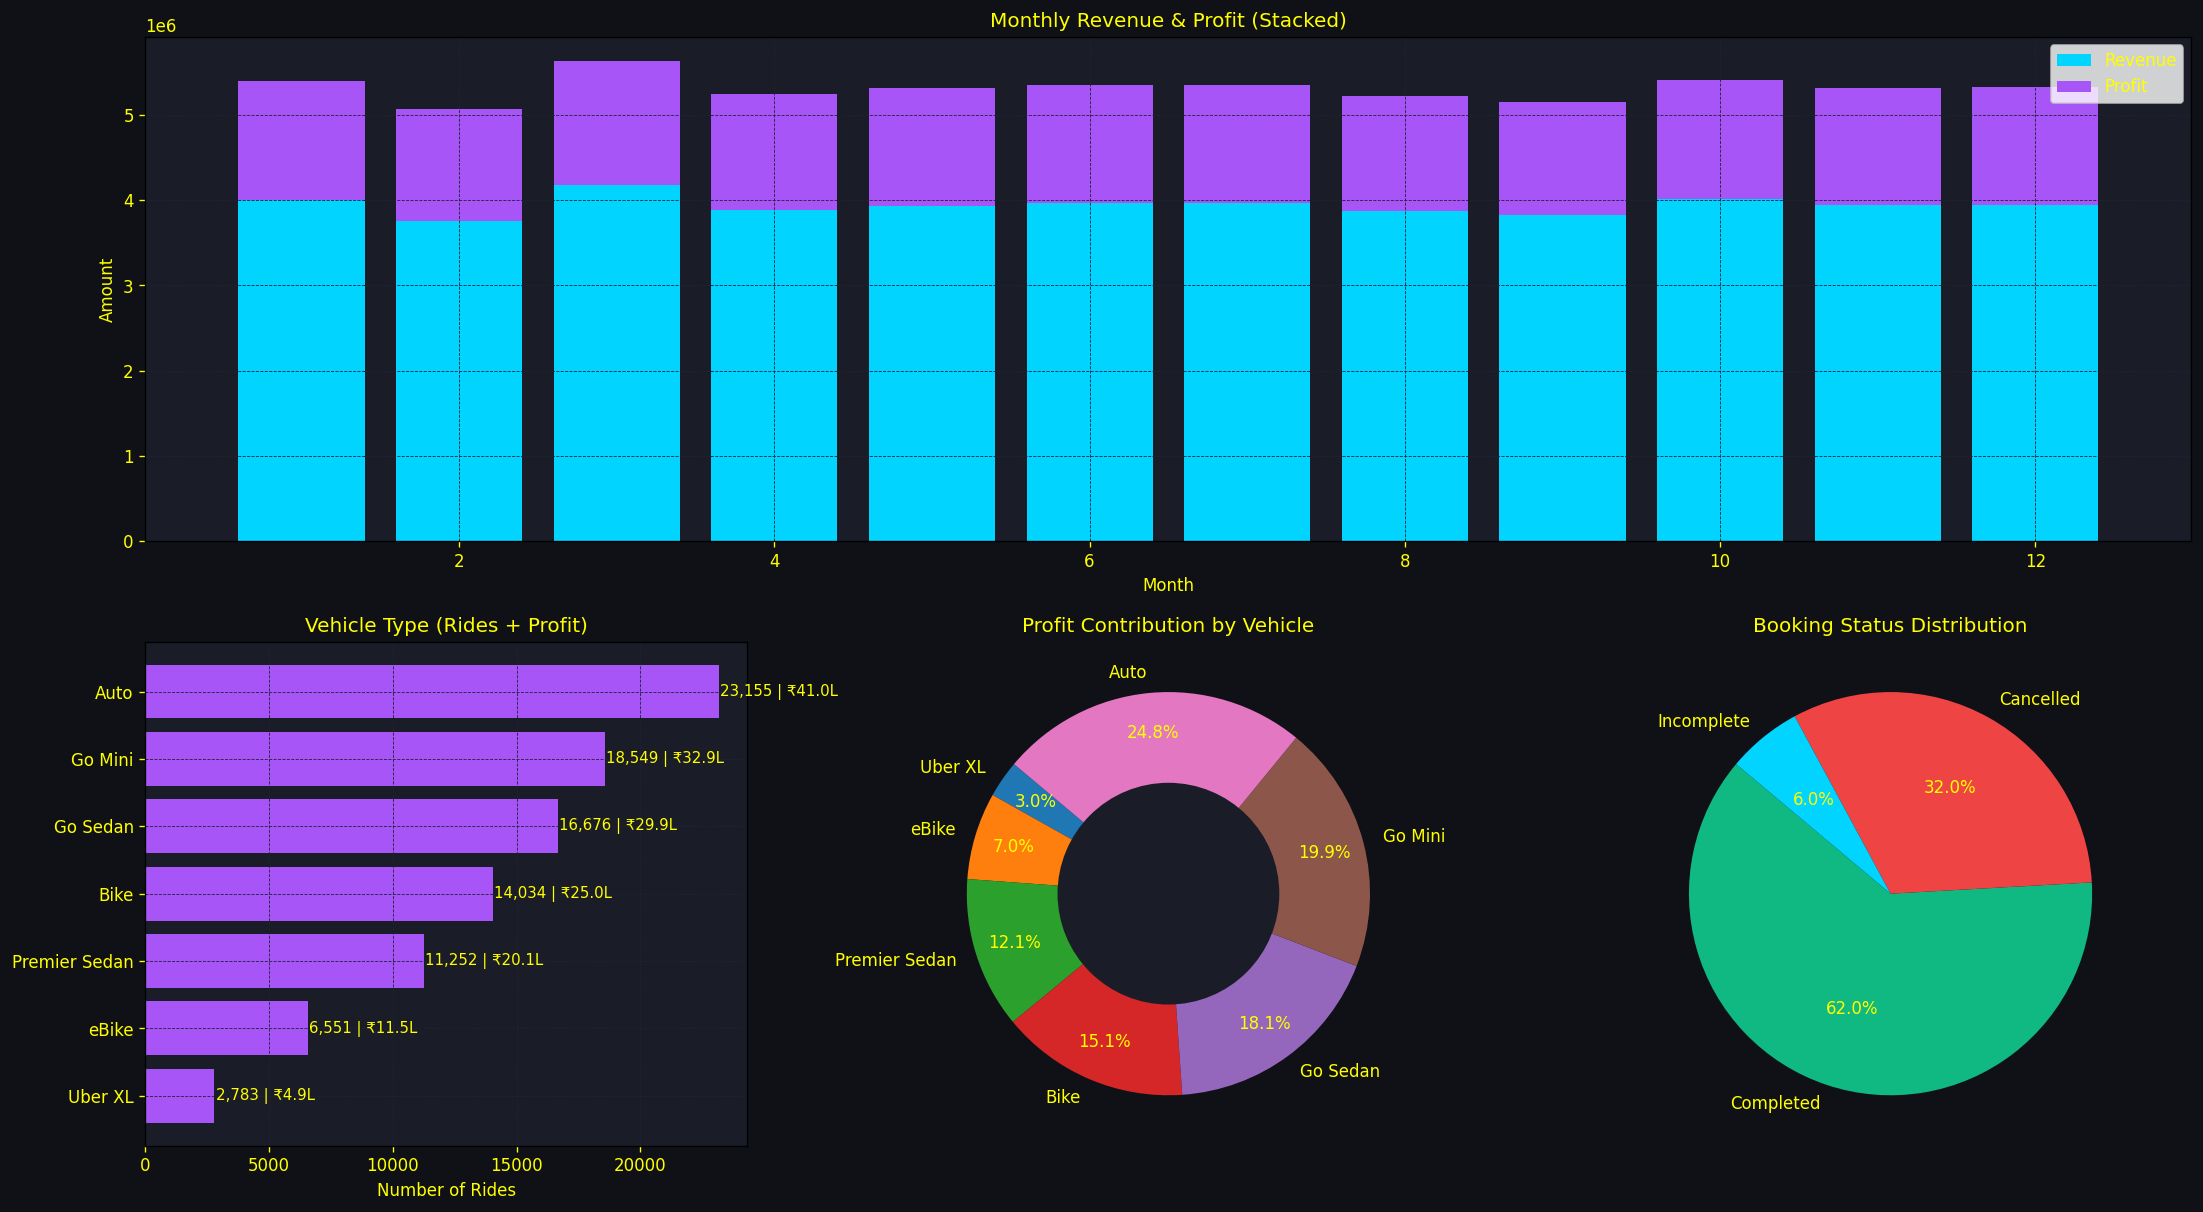

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import warnings
warnings.filterwarnings("ignore")

# ── 1. CONFIGURATION ────────────────────────────────────────
CONFIG = {
    "data_path": "/content/ncr_ride_bookings.csv",
    "output_path": "/mnt/user-data/outputs/ncr_dashboard.png",
    "cost_ratio": 0.65,
    "target_cancellation_rate": 0.15
}

COLORS = {
    "bg": "#0F1117",
    "card": "#1A1D27",
    "accent1": "#00D4FF",
    "accent2": "#A855F7",
    "green": "#10B981",
    "red": "#EF4444",
    "text": "#E2E8F0",
    "subtext": "#94A3B8",
    "grid": "#1E2235"
}

# ── 2. DATA LOADING ────────────────────────────────────────
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")
    df = pd.read_csv(path)
    print(f"✅ Data loaded: {df.shape}")
    return df


# ── 3. DATA CLEANING ────────────────────────────────────────
def clean_data(df):
    df = df.copy()

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    df['Booking ID'] = df['Booking ID'].astype(str).str.replace('"', '').str.strip()
    df['Customer ID'] = df['Customer ID'].astype(str).str.replace('"', '').str.strip()

    status_map = {
        'Completed': 'Completed',
        'Cancelled by Customer': 'Cancelled',
        'Cancelled by Driver': 'Cancelled',
        'No Driver Found': 'Cancelled',
        'Incomplete': 'Incomplete',
    }

    df['Status_Clean'] = df['Booking Status'].map(status_map).fillna('Other')

    unknown_status = set(df['Booking Status']) - set(status_map.keys())
    if unknown_status:
        print(f"⚠ Unknown statuses found: {unknown_status}")

    df['Vehicle Type'] = df['Vehicle Type'].str.strip()

    df = df.dropna(subset=['Date'])

    return df


# ── 4. FEATURE ENGINEERING ────────────────────────────────────────
def feature_engineering(df, config):
    df = df.copy()

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%b')

    df['Revenue'] = df['Booking Value']
    df['Cost'] = df['Revenue'] * config['cost_ratio']
    df['Profit'] = df['Revenue'] - df['Cost']

    return df


# ── 5. KPI CALCULATIONS ────────────────────────────────────────
def calculate_kpis(df):
    total = len(df)
    completed = (df['Status_Clean'] == 'Completed').sum()
    cancelled = (df['Status_Clean'] == 'Cancelled').sum()
    incomplete = (df['Status_Clean'] == 'Incomplete').sum()

    effective_total = completed + cancelled
    cancellation_rate = (cancelled / effective_total) * 100 if effective_total else 0

    revenue = df['Revenue'].sum()
    profit = df['Profit'].sum()
    avg_rev = df[df['Status_Clean'] == 'Completed']['Revenue'].mean()

    return {
        "total": total,
        "completed": completed,
        "cancelled": cancelled,
        "incomplete": incomplete,
        "cancellation_rate": cancellation_rate,
        "revenue": revenue,
        "profit": profit,
        "avg_revenue": avg_rev
    }


# ── 6. DASHBOARD ────────────────────────────────────────
def create_dashboard(df, kpis, config):

    plt.rcParams['text.color'] = 'yellow'
    plt.rcParams['axes.labelcolor'] = 'yellow'
    plt.rcParams['xtick.color'] = 'yellow'
    plt.rcParams['ytick.color'] = 'yellow'

    fig = plt.figure(figsize=(22, 12), facecolor=COLORS["bg"])
    gs = GridSpec(2, 3, figure=fig)

    # ── 1. STACKED BAR: Revenue & Profit ─────────────────
    ax1 = fig.add_subplot(gs[0, :])

    monthly = (
        df[df['Status_Clean'] == 'Completed']
        .groupby(['Year','Month'])[['Revenue','Profit']]
        .sum()
        .reset_index()
    )

    x = monthly['Month']

    ax1.bar(x, monthly['Revenue'], color=COLORS['accent1'], label='Revenue')
    ax1.bar(x, monthly['Profit'], bottom=monthly['Revenue'], color=COLORS['accent2'], label='Profit')

    ax1.set_title("Monthly Revenue & Profit (Stacked)")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Amount")
    ax1.legend()
    ax1.set_facecolor(COLORS["card"])
    ax1.grid(color=COLORS["grid"], linestyle='--', linewidth=0.5)

    # ── 2. Vehicle Type Bar Chart ─────────
    ax2 = fig.add_subplot(gs[1, 0])

    vehicle_summary = (
        df[df['Status_Clean']=='Completed']
        .groupby('Vehicle Type')
        .agg(Rides=('Booking ID','count'), Profit=('Profit','sum'))
        .sort_values('Rides', ascending=True)
    )

    ax2.barh(vehicle_summary.index, vehicle_summary['Rides'], color=COLORS['accent2'])

    for i, (rides, profit) in enumerate(zip(vehicle_summary['Rides'], vehicle_summary['Profit'])):
        ax2.text(rides + 50, i,
                 f"{rides:,} | ₹{profit/1e5:.1f}L",
                 va='center', color='yellow', fontsize=9)

    ax2.set_title("Vehicle Type (Rides + Profit)")
    ax2.set_xlabel("Number of Rides")
    ax2.set_facecolor(COLORS["card"])
    ax2.grid(color=COLORS["grid"], linestyle='--', linewidth=0.5)

    # ── 3. Donut Chart ─────────
    ax3 = fig.add_subplot(gs[1, 1])

    profit_by_vehicle = vehicle_summary['Profit']

    wedges, texts, autotexts = ax3.pie(
        profit_by_vehicle,
        labels=profit_by_vehicle.index,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.8
    )

    centre_circle = plt.Circle((0, 0), 0.55, fc=COLORS["card"])
    ax3.add_artist(centre_circle)

    for t in texts + autotexts:
        t.set_color('yellow')

    ax3.set_title("Profit Contribution by Vehicle")
    ax3.set_facecolor(COLORS["card"])

    # ── 4. PIE: Completed + Cancelled + Incomplete ─────────
    ax4 = fig.add_subplot(gs[1, 2])

    status_counts = df['Status_Clean'].value_counts()

    labels = ['Completed', 'Cancelled', 'Incomplete']
    values = [
        status_counts.get('Completed', 0),
        status_counts.get('Cancelled', 0),
        status_counts.get('Incomplete', 0)
    ]

    colors = [COLORS['green'], COLORS['red'], COLORS['accent1']]

    wedges, texts, autotexts = ax4.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors
    )

    for t in texts + autotexts:
        t.set_color('yellow')

    ax4.set_title("Booking Status Distribution")
    ax4.set_facecolor(COLORS["card"])

    # ── SAVE ─────────────────────────
    output_dir = os.path.dirname(config["output_path"])
    os.makedirs(output_dir, exist_ok=True)

    plt.savefig(config["output_path"], dpi=120, bbox_inches='tight')
    plt.close()

    print(f"✅ Dashboard saved at {config['output_path']}")


# ── 7. INSIGHTS ────────────────────────────────────────
def generate_insights(kpis):
    print("\n✨ KEY INSIGHTS")
    print("-" * 50)

    print(f"Total Revenue: ₹{kpis['revenue']:,.0f}")
    print(f"Total Profit : ₹{kpis['profit']:,.0f}")
    print(f"Cancellation Rate: {kpis['cancellation_rate']:.2f}%")

    potential_revenue = kpis['cancelled'] * 0.5 * kpis['avg_revenue']
    print(f"💡 Potential Revenue Gain: ₹{potential_revenue:,.0f}")


# ── 8. MAIN PIPELINE ────────────────────────────────────────
def run_pipeline():
    df = load_data(CONFIG["data_path"])
    df = clean_data(df)
    df = feature_engineering(df, CONFIG)
    kpis = calculate_kpis(df)

    create_dashboard(df, kpis, CONFIG)
    generate_insights(kpis)

    print("\n✅ Analysis Complete")


# ── EXECUTION ────────────────────────────────────────
if __name__ == "__main__":
    run_pipeline()

    from IPython.display import Image
Image(filename='/mnt/user-data/outputs/ncr_dashboard.png')